# House Price Prediction using Machine Learning

## Project Objective

The objective is to build a machine learning regression system that predicts house sale prices from property characteristics. The project follows an end-to-end workflow from exploratory data analysis and baseline modeling to model selection, hyperparameter tuning, final evaluation, and API deployment.

## Project Workflow

Business Understanding → Data Understanding → EDA → Data Preparation → Preprocessing Pipeline → Baseline Models → Log vs Yeo-Johnson + Advanced Models → Top-3 Selection → RandomizedSearchCV → GridSearchCV → Tuned Model Comparison → Final Test Evaluation → Save Pipeline → FastAPI Prediction & Retraining → Conclusion

> **Important:** The test set is kept separate from model selection and hyperparameter tuning and is used only for final evaluation.

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 2. Load the Dataset


In [2]:
import pandas as pd
df = pd.read_csv("train.csv")

## 3. Initial Data Exploration

We inspect the dataset structure, data types, numerical/categorical variables, missing values and duplicate rows before modeling.


In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.shape

(1460, 81)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
# Summary statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [7]:
# Summary statistics for categorical features
df.describe(include="object").T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


In [8]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("MissingCount")
      .assign(MissingPercentage=lambda x: (x["MissingCount"] / len(df) * 100).round(2))
      .query("MissingCount > 0")
      .sort_values("MissingCount", ascending=False)
)

missing_summary

,MissingCount,MissingPercentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [9]:
print("Duplicate rows:", df.duplicated().sum())

numeric_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))


Duplicate rows: 0
Number of numerical features: 38
Number of categorical features: 43


## 4. Exploratory Data Analysis

### 4.1 Target Variable — `SalePrice`

The target distribution is inspected for skewness and potential outliers. 


In [10]:
print("Mean:", df["SalePrice"].mean())
print("Median:", df["SalePrice"].median())
print("Skewness:", df["SalePrice"].skew())


Mean: 180921.19589041095
Median: 163000.0
Skewness: 1.8828757597682129


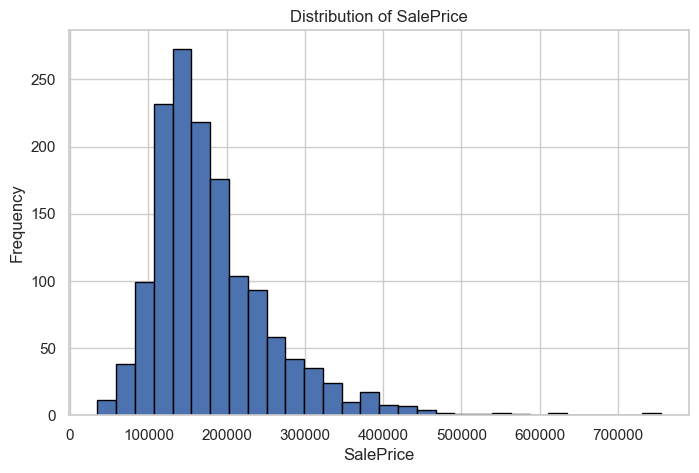

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df["SalePrice"], bins=30, edgecolor="black")
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()


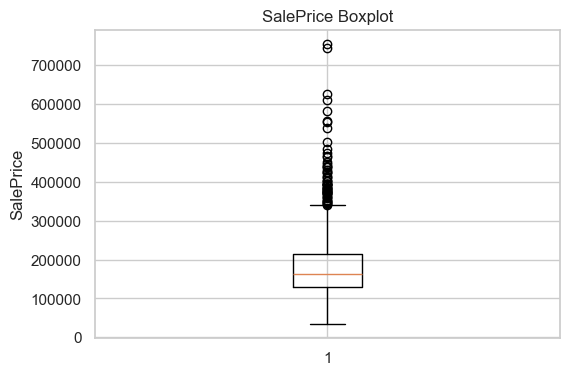

In [12]:
plt.figure(figsize=(6, 4))
plt.boxplot(df["SalePrice"])
plt.title("SalePrice Boxplot")
plt.ylabel("SalePrice")
plt.show()


### 4.2 Skewness of Important Numerical Features

The current analysis identified `SalePrice`, `LotArea` and `GrLivArea` as highly/noticeably skewed. We record their skewness here; Log vs Yeo-Johnson will be implemented in the next phase without fitting transformations on the full dataset.


In [13]:
skew_features = ["SalePrice", "LotArea", "GrLivArea"]

skewness_summary = pd.DataFrame({
    "Feature": skew_features,
    "Skewness": [df[col].skew() for col in skew_features]
}).sort_values("Skewness", key=lambda s: s.abs(), ascending=False)

skewness_summary


,Feature,Skewness
1,LotArea,12.207688
0,SalePrice,1.882876
2,GrLivArea,1.366560


### 4.3 Numerical Feature Analysis

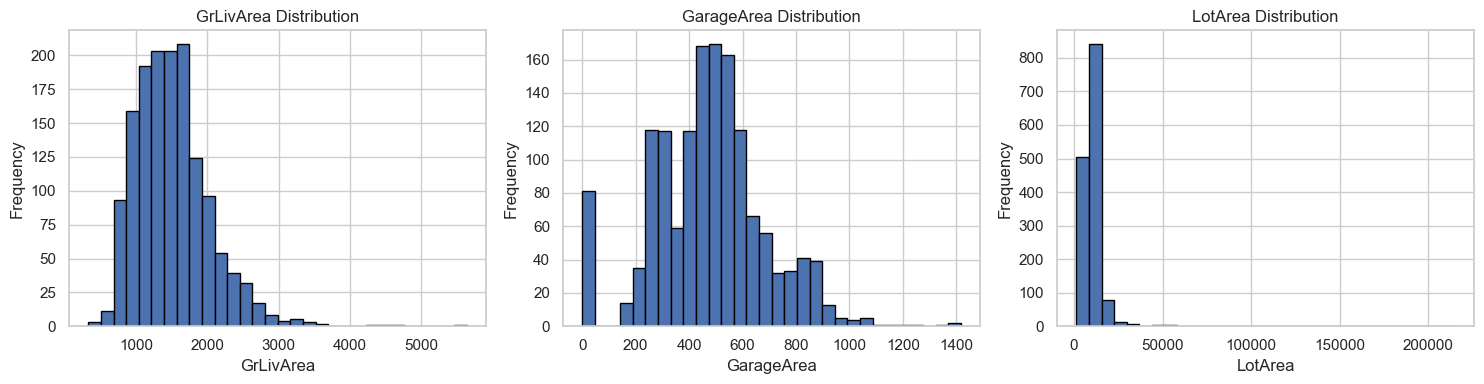

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["GrLivArea", "GarageArea", "LotArea"]):
    ax.hist(df[col], bins=30, edgecolor="black")
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [15]:
corr_with_target = (
    df.corr(numeric_only=True)["SalePrice"]
      .sort_values(ascending=False)
)

corr_with_target.head(15)


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

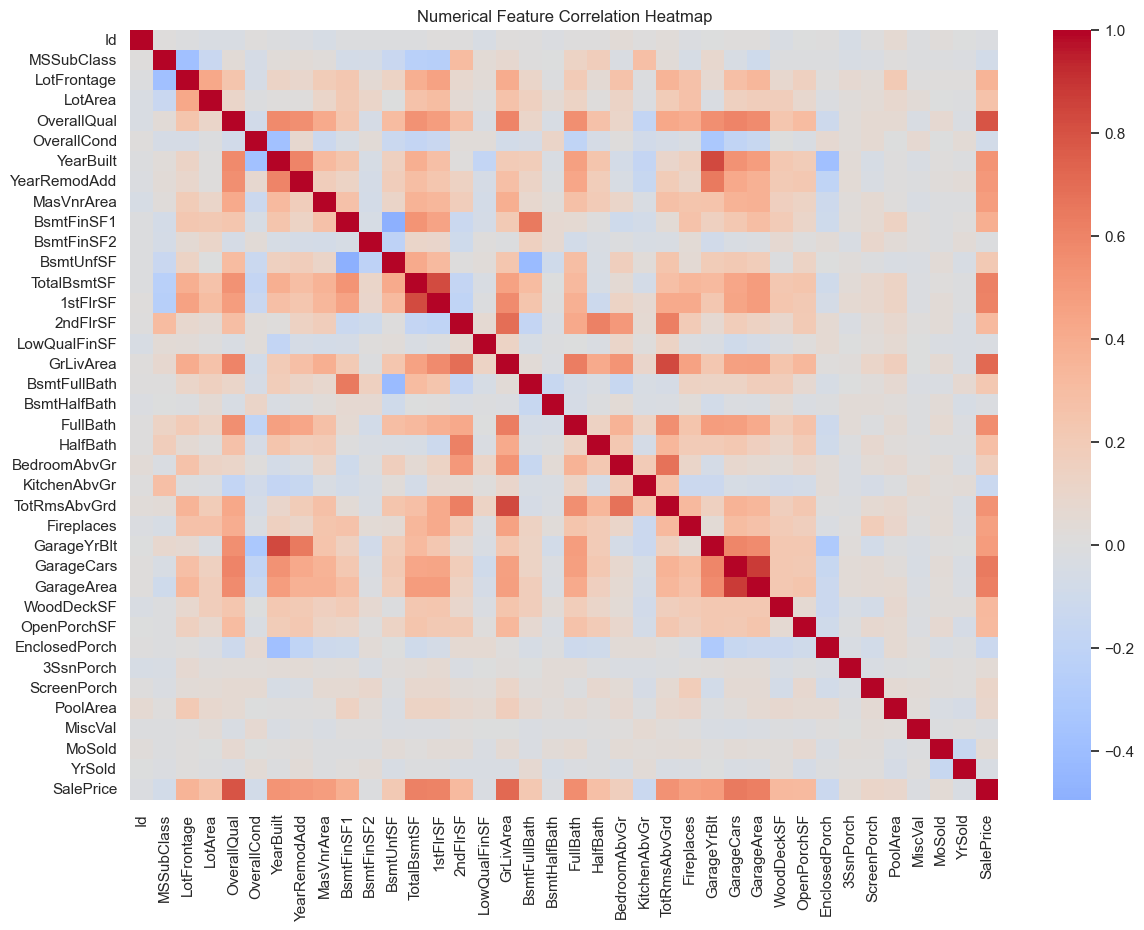

In [16]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Numerical Feature Correlation Heatmap")
plt.show()


### 4.4 Categorical Feature Analysis

In [17]:
print("Neighborhood value counts:")
display(df["Neighborhood"].value_counts().head(15))

print("\nAverage SalePrice by Neighborhood:")
display(
    df.groupby("Neighborhood")["SalePrice"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)


Neighborhood value counts:


Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
Name: count, dtype: int64


Average SalePrice by Neighborhood:


Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
Name: SalePrice, dtype: float64

MSZoning value counts:


MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

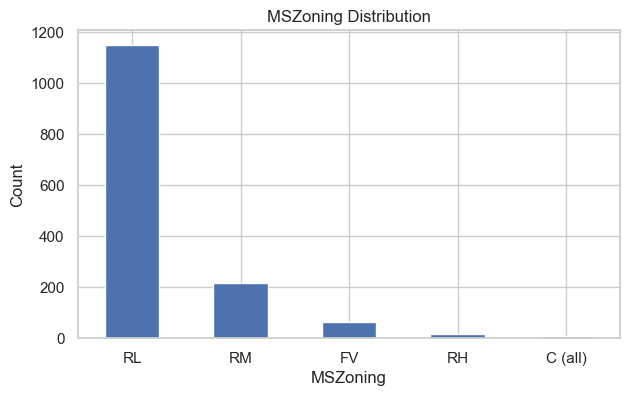

In [18]:
print("MSZoning value counts:")
display(df["MSZoning"].value_counts())

plt.figure(figsize=(7, 4))
df["MSZoning"].value_counts().plot(kind="bar")
plt.title("MSZoning Distribution")
plt.xlabel("MSZoning")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


### 4.5 Relationship with the Target

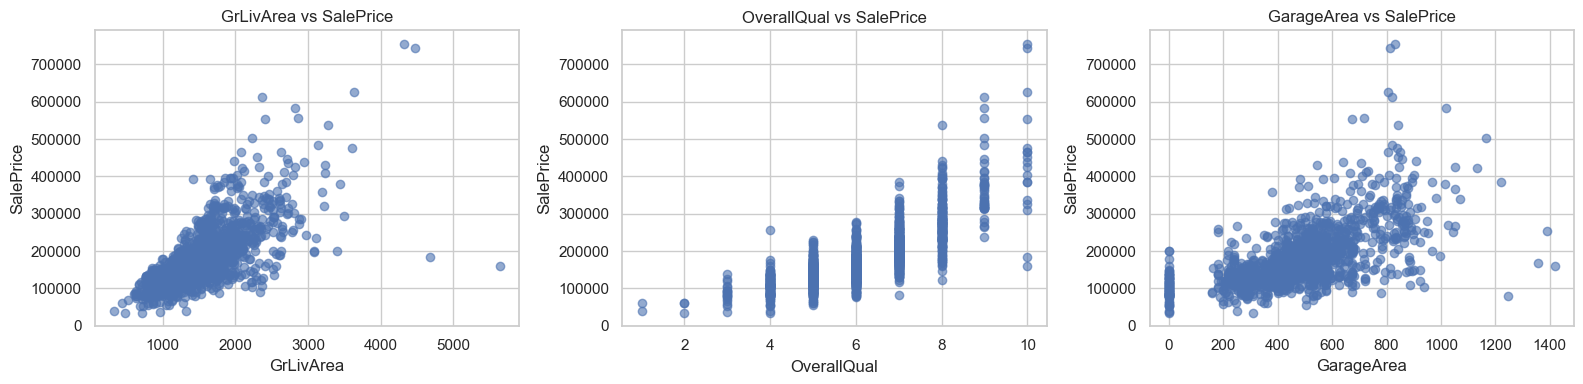

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

relationships = [
    ("GrLivArea", "GrLivArea vs SalePrice"),
    ("OverallQual", "OverallQual vs SalePrice"),
    ("GarageArea", "GarageArea vs SalePrice"),
]

for ax, (feature, title) in zip(axes, relationships):
    ax.scatter(df[feature], df["SalePrice"], alpha=0.6)
    ax.set_xlabel(feature)
    ax.set_ylabel("SalePrice")
    ax.set_title(title)

plt.tight_layout()
plt.show()


## 5. Data Preparation and Train-Test Split

In this :

- `Id` is removed because it is an identifier, not a useful predictive feature.
- Extremely sparse columns identified during the original analysis are removed.
- **No manual imputation is performed.**
- Numerical missing values are handled by `SimpleImputer(strategy="median")`.
- Categorical missing values are handled by `SimpleImputer(strategy="most_frequent")`.
- Categorical variables are one-hot encoded with `handle_unknown="ignore"`.

This gives us a single reusable preprocessing workflow.


In [20]:
# Work on a fresh copy so the original dataframe remains available for EDA.
model_df = df.copy()

# Identifier column is not used as a predictive feature.
model_df = model_df.drop(columns=["Id"], errors="ignore")

# These columns were identified in the original analysis as extremely sparse.
# They are removed to keep the baseline preprocessing workflow consistent.
SPARSE_COLUMNS = ["PoolQC", "MiscFeature", "Alley", "Fence"]

model_df = model_df.drop(columns=SPARSE_COLUMNS, errors="ignore")

print("Modeling dataset shape:", model_df.shape)


Modeling dataset shape: (1460, 76)


In [21]:
X = model_df.drop(columns="SalePrice")
y = model_df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (1168, 75)
X_test : (292, 75)
y_train: (1168,)
y_test : (292,)


## 6. Preprocessing Pipeline

All learned preprocessing steps are fitted **only on the training data** through the model pipeline.

### Numerical features
1. Median imputation

### Categorical features
1. Most-frequent imputation
2. One-hot encoding

`handle_unknown="ignore"` ensures that an unseen category in the test set or future API input does not break the pipeline.


In [22]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numerical features: 36
Categorical features: 39


## 7. Baseline Model Comparison

A machine learning pipeline combines data preprocessing and model training
into one workflow. This ensures that the same preprocessing steps are applied
consistently during training and prediction.


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 20385.821259310487
RMSE: 31260.22734277067
R²  : 0.8725997060456092


In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("---------------------")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree Results
---------------------
MAE : 28348.431506849316
RMSE: 44213.49355597969
R²  : 0.7451434320234032


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 17420.846575342468
RMSE: 28681.62725807692
R²  : 0.8927508791737634


In [26]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

# Create Gradient Boosting pipeline
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

# Train the pipeline
gb_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_pipeline.predict(X_test)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Gradient Boosting Results
-------------------------
MAE : 16627.65799270119
RMSE: 27140.575283257007
R²  : 0.9039661669127013


In [28]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    gb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross-validation R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation R² scores: [0.86713247 0.76029202 0.85546114 0.88907462 0.90473069]
Mean CV R²: 0.8553381861917554
Standard deviation: 0.05049883244726767


## 8. Transformation Experiment and Advanced Model Comparison

The EDA identified substantial skewness in `SalePrice`, `LotArea`, and `GrLivArea`. Before selecting the advanced model, two transformation strategies are evaluated using the training data and 5-fold cross-validation:

1. **Log transformation (`log1p`)** for `LotArea` and the `SalePrice` target.
2. **Yeo-Johnson transformation** for `LotArea` and the `SalePrice` target.

The six regression models are evaluated under both transformations:
XGBoost, LightGBM, CatBoost, Extra Trees, HistGradientBoosting, and AdaBoost.

The transformation is selected using cross-validation model performance. The selected transformation is then carried forward to Top-3 selection and hyperparameter tuning.

In [29]:
from sklearn.model_selection import KFold, RandomizedSearchCV, GridSearchCV, cross_validate
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import joblib

In [30]:
# Reuse the train/test split and feature lists created in Sections 5–6.
other_numeric = [c for c in numeric_features if c != 'LotArea']
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_preprocessor(transformation):
    num_pipe=Pipeline([('imputer',SimpleImputer(strategy='median'))])
    if transformation=='log':
        lot_pipe=Pipeline([('imputer',SimpleImputer(strategy='median')),('transform',FunctionTransformer(np.log1p,feature_names_out='one-to-one'))])
        target_transform=FunctionTransformer(np.log1p,inverse_func=np.expm1,validate=False)
    else:
        lot_pipe=Pipeline([('imputer',SimpleImputer(strategy='median')),('transform',PowerTransformer(method='yeo-johnson',standardize=False))])
        target_transform=PowerTransformer(method='yeo-johnson',standardize=False)
    cat_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])
    pre=ColumnTransformer([('num',num_pipe,other_numeric),('lotarea',lot_pipe,['LotArea']),('cat',cat_pipe,categorical_features)])
    return pre,target_transform

class CatBoostSklearnWrapper(BaseEstimator,RegressorMixin):
    def __init__(self,iterations=300,depth=6,learning_rate=0.05,l2_leaf_reg=3,random_seed=42,verbose=False,thread_count=2):
        self.iterations=iterations; self.depth=depth; self.learning_rate=learning_rate; self.l2_leaf_reg=l2_leaf_reg; self.random_seed=random_seed; self.verbose=verbose; self.thread_count=thread_count
    def fit(self,X,y):
        self.model_=CatBoostRegressor(iterations=self.iterations,depth=self.depth,learning_rate=self.learning_rate,l2_leaf_reg=self.l2_leaf_reg,random_seed=self.random_seed,verbose=self.verbose,thread_count=self.thread_count,loss_function='RMSE'); self.model_.fit(X,y); return self
    def predict(self,X): return self.model_.predict(X)

models={
'XGBoost':XGBRegressor(n_estimators=300,max_depth=4,learning_rate=.05,subsample=.8,colsample_bytree=.8,objective='reg:squarederror',random_state=RANDOM_STATE,n_jobs=-1),
'LightGBM':LGBMRegressor(n_estimators=300,num_leaves=31,learning_rate=.05,subsample=.8,colsample_bytree=.8,random_state=RANDOM_STATE,n_jobs=-1,verbosity=-1),
'CatBoost':CatBoostSklearnWrapper(random_seed=RANDOM_STATE),
'Extra Trees':ExtraTreesRegressor(n_estimators=300,random_state=RANDOM_STATE,n_jobs=-1),
'HistGradientBoosting':HistGradientBoostingRegressor(max_iter=300,learning_rate=.05,max_leaf_nodes=31,l2_regularization=1,random_state=RANDOM_STATE),
'AdaBoost':AdaBoostRegressor(n_estimators=300,learning_rate=.05,random_state=RANDOM_STATE)}

def build_estimator(model,transformation):
    pre,target=make_preprocessor(transformation)
    pipe=Pipeline([('preprocessor',pre),('model',model)])
    return TransformedTargetRegressor(regressor=pipe,transformer=target)

In [31]:
comparison=[]
for transformation in ['log','yeo-johnson']:
    for name,model in models.items():
        est=build_estimator(model,transformation)
        s=cross_validate(est,X_train,y_train,cv=cv,scoring={'R2':'r2','RMSE':'neg_root_mean_squared_error','MAE':'neg_mean_absolute_error'},n_jobs=1)
        comparison.append({'Transformation':transformation,'Model':name,'CV R2 Mean':s['test_R2'].mean(),'CV R2 Std':s['test_R2'].std(),'CV RMSE Mean':-s['test_RMSE'].mean(),'CV MAE Mean':-s['test_MAE'].mean()})
comparison_df=pd.DataFrame(comparison).sort_values('CV R2 Mean',ascending=False).reset_index(drop=True)
display(comparison_df)
best_transformation=comparison_df.groupby('Transformation')['CV R2 Mean'].mean().idxmax()
print('Selected transformation:',best_transformation)

,Transformation,Model,CV R2 Mean,CV R2 Std,CV RMSE Mean,CV MAE Mean
0,log,CatBoost,0.881552,0.027778,26428.421064,15172.855626
1,yeo-johnson,LightGBM,0.875135,0.027316,27176.093721,15918.399843
2,yeo-johnson,CatBoost,0.873400,0.035665,27247.397013,15272.868935
3,log,LightGBM,0.873022,0.031108,27377.354524,15836.502346
4,yeo-johnson,HistGradientBoosting,0.872355,0.028644,27489.313957,16177.166391
5,log,XGBoost,0.870438,0.045015,27471.416406,15552.507031
6,yeo-johnson,XGBoost,0.867942,0.036128,27873.436719,15728.298437
7,log,HistGradientBoosting,0.867570,0.032049,27982.670901,16308.957722
8,log,Extra Trees,0.835253,0.028996,31228.674893,18187.965798
9,yeo-johnson,Extra Trees,0.834309,0.025864,31324.426929,18183.084729


Selected transformation: log


## 9. Top 3 Model Selection

The top three models are selected from the advanced-model comparison using the best transformation and mean cross-validation R².

In [32]:
top3=(comparison_df[comparison_df.Transformation==best_transformation].head(3)).reset_index(drop=True)
display(top3)
top3_names=top3.Model.tolist()

,Transformation,Model,CV R2 Mean,CV R2 Std,CV RMSE Mean,CV MAE Mean
0,log,CatBoost,0.881552,0.027778,26428.421064,15172.855626
1,log,LightGBM,0.873022,0.031108,27377.354524,15836.502346
2,log,XGBoost,0.870438,0.045015,27471.416406,15552.507031


## 10. RandomizedSearchCV on Top 3 Models


In [33]:
spaces={
'XGBoost':{'regressor__model__n_estimators':[200,300,500],'regressor__model__max_depth':[3,4,5],'regressor__model__learning_rate':[.03,.05,.1],'regressor__model__subsample':[.8,1.0]},
'LightGBM':{'regressor__model__n_estimators':[200,300,500],'regressor__model__num_leaves':[15,31,63],'regressor__model__learning_rate':[.03,.05,.1]},
'CatBoost':{'regressor__model__iterations':[200,300,500],'regressor__model__depth':[5,6,7],'regressor__model__learning_rate':[.03,.05,.1]},
'Extra Trees':{'regressor__model__n_estimators':[200,300,500],'regressor__model__max_depth':[None,10,20],'regressor__model__min_samples_leaf':[1,2,4]},
'HistGradientBoosting':{'regressor__model__max_iter':[200,300,500],'regressor__model__learning_rate':[.03,.05,.1],'regressor__model__max_leaf_nodes':[15,31,63]},
'AdaBoost':{'regressor__model__n_estimators':[100,200,300],'regressor__model__learning_rate':[.03,.05,.1]}}
random_searches={}; rs_rows=[]
for name in top3_names:
    rs=RandomizedSearchCV(build_estimator(models[name],best_transformation),spaces[name],n_iter=15,cv=cv,scoring='r2',random_state=RANDOM_STATE,n_jobs=1,refit=True,verbose=1)
    rs.fit(X_train,y_train); random_searches[name]=rs
    rs_rows.append({'Model':name,'Search':'RandomizedSearchCV','CV R2':rs.best_score_,'Best Parameters':rs.best_params_})
random_results=pd.DataFrame(rs_rows).sort_values('CV R2',ascending=False); display(random_results)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits


,Model,Search,CV R2,Best Parameters
0,CatBoost,RandomizedSearchCV,0.886824,"{'regressor__model__learning_rate': 0.1, 'regr..."
1,LightGBM,RandomizedSearchCV,0.874661,"{'regressor__model__num_leaves': 15, 'regresso..."
2,XGBoost,RandomizedSearchCV,0.870781,"{'regressor__model__subsample': 1.0, 'regresso..."


## 11. GridSearchCV 


In [34]:
grid_names=random_results.Model.head(2).tolist()
grid_spaces={
'XGBoost':{'regressor__model__n_estimators':[300,500],'regressor__model__max_depth':[3,4],'regressor__model__learning_rate':[.03,.05]},
'LightGBM':{'regressor__model__n_estimators':[300,500],'regressor__model__num_leaves':[15,31],'regressor__model__learning_rate':[.03,.05]},
'CatBoost':{'regressor__model__iterations':[300,500],'regressor__model__depth':[5,6],'regressor__model__learning_rate':[.03,.05]},
'Extra Trees':{'regressor__model__n_estimators':[300,500],'regressor__model__min_samples_leaf':[1,2]},
'HistGradientBoosting':{'regressor__model__max_iter':[300,500],'regressor__model__learning_rate':[.03,.05],'regressor__model__max_leaf_nodes':[31,63]},
'AdaBoost':{'regressor__model__n_estimators':[200,300],'regressor__model__learning_rate':[.03,.05]}}
grid_searches={}; grid_rows=[]
for name in grid_names:
    gs=GridSearchCV(build_estimator(models[name],best_transformation),grid_spaces[name],cv=cv,scoring='r2',n_jobs=1,refit=True,verbose=1)
    gs.fit(X_train,y_train); grid_searches[name]=gs
    grid_rows.append({'Model':name,'Search':'GridSearchCV','CV R2':gs.best_score_,'Best Parameters':gs.best_params_})
grid_results=pd.DataFrame(grid_rows).sort_values('CV R2',ascending=False); display(grid_results)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,Model,Search,CV R2,Best Parameters
0,CatBoost,GridSearchCV,0.886071,"{'regressor__model__depth': 6, 'regressor__mod..."
1,LightGBM,GridSearchCV,0.874895,"{'regressor__model__learning_rate': 0.03, 'reg..."


## 12. Tuned Model Comparison and Final Model Selection

All tuned candidates are compared using cross-validation R². The highest-scoring tuned estimator is selected as the final model. The held-out test set remains untouched until the next section.

In [35]:
candidates=[]
for name,rs in random_searches.items(): candidates.append((name,'RandomizedSearchCV',rs.best_score_,rs.best_estimator_))
for name,gs in grid_searches.items(): candidates.append((name,'GridSearchCV',gs.best_score_,gs.best_estimator_))
tuned_df=pd.DataFrame([{'Model':a,'Search':b,'CV R2':c} for a,b,c,_ in candidates]).sort_values('CV R2',ascending=False)
display(tuned_df)
best=max(candidates,key=lambda x:x[2]); final_model=best[3]
print('Final model:',best[0]); print('Search:',best[1]); print('CV R2:',best[2])

,Model,Search,CV R2
0,CatBoost,RandomizedSearchCV,0.886824
3,CatBoost,GridSearchCV,0.886071
4,LightGBM,GridSearchCV,0.874895
1,LightGBM,RandomizedSearchCV,0.874661
2,XGBoost,RandomizedSearchCV,0.870781


Final model: CatBoost
Search: RandomizedSearchCV
CV R2: 0.8868237985317851


## 13. Final Test-Set Evaluation

The selected final pipeline is evaluated once on the untouched test set using MAE, RMSE, and R².

,Metric,Value
0,MAE,15158.445900
1,RMSE,26245.854344
2,R2,0.910194


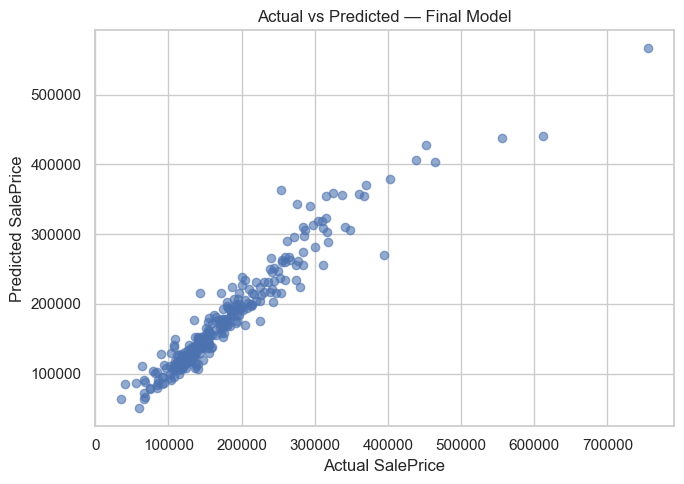

In [36]:
pred=final_model.predict(X_test)
final_metrics=pd.DataFrame({'Metric':['MAE','RMSE','R2'],'Value':[mean_absolute_error(y_test,pred),np.sqrt(mean_squared_error(y_test,pred)),r2_score(y_test,pred)]})
display(final_metrics)
plt.figure(figsize=(7,5)); plt.scatter(y_test,pred,alpha=.6); plt.xlabel('Actual SalePrice'); plt.ylabel('Predicted SalePrice'); plt.title('Actual vs Predicted — Final Model'); plt.tight_layout(); plt.show()

## 14. Save the Final Prediction Pipeline


In [37]:
MODEL_PATH='house_price_prediction_pipeline.joblib'
joblib.dump(final_model,MODEL_PATH)
print('Saved:',MODEL_PATH)

Saved: house_price_prediction_pipeline.joblib


## 15. FastAPI Prediction and Retraining
The API uses the saved pipeline for prediction. A `/retrain` endpoint accepts a new labeled CSV containing `SalePrice`, refits the same pipeline and replaces the saved model. This supports supervised retraining as new labeled training data arrives.


In [38]:
# Save this as app.py
# Run with: uvicorn app:app --reload

from fastapi import FastAPI, UploadFile, File, HTTPException
from pydantic import BaseModel
from io import BytesIO
from pathlib import Path
import pandas as pd
import joblib

MODEL_PATH=Path('house_price_prediction_pipeline.joblib')
DROP_COLUMNS=['Id','PoolQC','MiscFeature','Alley','Fence']
app=FastAPI(title='House Price Prediction API')

class HouseFeatures(BaseModel):
    data: dict

def load_model():
    if not MODEL_PATH.exists(): raise HTTPException(500,'Trained model not found')
    return joblib.load(MODEL_PATH)

@app.get('/')
def root(): return {'message':'House Price Prediction API is running'}

@app.post('/predict')
def predict(payload: HouseFeatures):
    model=load_model(); X_new=pd.DataFrame([payload.data]).drop(columns=DROP_COLUMNS,errors='ignore')
    return {'predicted_sale_price':round(float(model.predict(X_new)[0]),2)}

@app.post('/retrain')
def retrain(file: UploadFile=File(...)):
    if not file.filename.lower().endswith('.csv'): raise HTTPException(400,'Upload a CSV file')
    data=pd.read_csv(BytesIO(file.file.read()))
    if 'SalePrice' not in data.columns: raise HTTPException(400,'CSV must contain SalePrice for supervised retraining')
    X_new=data.drop(columns=['SalePrice']+DROP_COLUMNS,errors='ignore'); y_new=data['SalePrice']
    model=load_model(); model.fit(X_new,y_new); joblib.dump(model,MODEL_PATH)
    return {'message':'Model retrained successfully','rows_used':len(data)}

### API Setup and Usage

Install: `pip install fastapi uvicorn python-multipart joblib`

Run: `uvicorn app:app --reload`

Open `/docs` for the Swagger UI.

**Prediction:** `/predict` accepts new house features and returns a predicted `SalePrice` using the saved pipeline.

**Retraining:** `/retrain` requires a new labeled CSV containing `SalePrice`, refits the same pipeline, and saves the updated model.

## 16. Final Conclusion

The project follows an end-to-end machine learning workflow: exploratory data analysis, data preparation, baseline modeling, skewness/transformation analysis, advanced model comparison, Top-3 selection, RandomizedSearchCV, GridSearchCV, tuned-model comparison, final test evaluation, pipeline persistence, and FastAPI deployment with prediction and supervised retraining.

The final model and metrics reported above represent the selected model after cross-validation and tuning and its performance on the untouched test set.